# Task 1 — The Fingerprint: Stylometry

Goal: prove the three classes are mathematically distinct **before any ML**, and lead with what's
counterintuitive.
1. **TTR and Hapax are computed on fixed-length samples**, because both are length-dependent.
2. **Every number gets one interpretation sentence.** The metric is the setup; the insight is the
   punchline.

In [2]:
%pip install -q spacy scikit-learn textstat numpy pandas matplotlib seaborn
%python -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [1]:
import re, json
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import spacy

In [2]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
DATA = Path("data/dataset")

In [3]:
def load_jsonl(p): return [json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
df = pd.DataFrame(load_jsonl(DATA/"dataset_full.jsonl"))
print(df["label"].value_counts())

label
human         420
ai_neutral    420
ai_styled     420
Name: count, dtype: int64


## 1. Feature primitives
Word tokeniser, fixed-window lexical metrics, sentence-rhythm, punctuation, syntax, readability.

In [ ]:
def ttr_fixed(text, sample=120):
    w = words(text)
    if len(w) < sample: return np.nan
    w = w[:sample]
    return len(set(w)) / len(w)

In [6]:
def hapax_fixed(text, sample=120):
    w = words(text)
    if len(w) < sample: return np.nan
    w = w[:sample]
    c = Counter(w)
    return sum(1 for x in c.values() if x == 1) / len(w)

In [7]:
def sentence_variance(text):
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    lens = [len(s.split()) for s in sents]
    return float(np.std(lens)) if len(lens) > 1 else 0.0

In [8]:
def punct_per_1k(text):
    n = max(len(words(text)) / 1000, 1e-6)
    em = text.count("\u2014") + text.count("--")
    return {"semicolon": text.count(";")/n, "emdash": em/n, "exclaim": text.count("!")/n,
            "question": text.count("?")/n, "colon": text.count(":")/n, "comma": text.count(",")/n}

In [9]:
def tree_depth(doc):
    def depth(tok): return 1 + max((depth(c) for c in tok.children), default=0)
    roots = [t for t in doc if t.head == t]
    return max((depth(r) for r in roots), default=0)

In [10]:
def syntax_features(text):
    doc = nlp(text)
    adj = sum(1 for t in doc if t.pos_ == "ADJ")
    noun = sum(1 for t in doc if t.pos_ in ("NOUN", "PROPN"))
    depths = [tree_depth(s.as_doc()) for s in doc.sents]
    return {"adj_noun": adj/noun if noun else 0.0,
            "tree_depth": float(np.mean(depths)) if depths else 0.0}

In [11]:
import textstat
def readability(text): return textstat.flesch_kincaid_grade(text)

## 2. Compute the full feature table
One row per paragraph; we'll aggregate by class next.

In [ ]:
def featurize(text):
    f = {"ttr": ttr_fixed(text), "hapax": hapax_fixed(text),
         "sent_var": sentence_variance(text), "fk_grade": readability(text)}
    f.update(punct_per_1k(text))
    f.update(syntax_features(text))
    return f

In [13]:
feats = pd.DataFrame([featurize(t) for t in df["text"]])
feats["label"] = df["label"].values
summary = feats.groupby("label").mean(numeric_only=True).round(3)
print(summary.T)
summary.to_csv("output/task-1/results_task1_summary.csv")

label       ai_neutral  ai_styled   human
ttr              0.678      0.631   0.690
hapax            0.529      0.502   0.549
sent_var         5.140      6.886  18.131
fk_grade        14.803     17.254  15.262
semicolon        0.000      0.114  15.008
emdash           0.000      0.000   5.888
exclaim          0.000      0.000   0.909
question         0.000      0.000   0.308
colon            0.000      0.014   2.409
comma           85.324     83.546  82.842
adj_noun         0.415      0.433   0.383
tree_depth       7.420      8.538   8.145


## 3. The surprises

In [ ]:
from scipy import stats
for col in ["ttr", "hapax", "sent_var", "semicolon", "adj_noun", "tree_depth", "fk_grade"]:
    h = feats[feats.label == "human"][col].dropna()
    a = feats[feats.label == "ai_neutral"][col].dropna()
    if len(h) > 1 and len(a) > 1:
        t, p = stats.ttest_ind(h, a, equal_var=False)
        print(f"{col:12s} human={h.mean():.3f}  ai={a.mean():.3f}  t={t:+.2f}  p={p:.2e}")

ttr          human=0.690  ai=0.678  t=+4.09  p=4.73e-05
hapax        human=0.549  ai=0.529  t=+4.72  p=2.80e-06
sent_var     human=18.131  ai=5.140  t=+27.46  p=2.43e-97
semicolon    human=15.008  ai=0.000  t=+30.24  p=2.26e-107
adj_noun     human=0.383  ai=0.415  t=-3.64  p=2.90e-04
tree_depth   human=8.145  ai=7.420  t=+7.81  p=2.88e-14
fk_grade     human=15.262  ai=14.803  t=+1.54  p=1.25e-01


## 4. KDE overlays for the surprising features
One plot per headline feature, all three classes on the same axis.

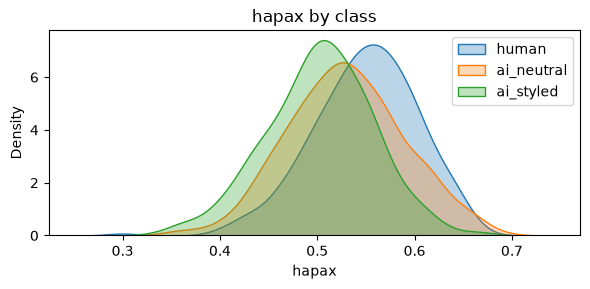

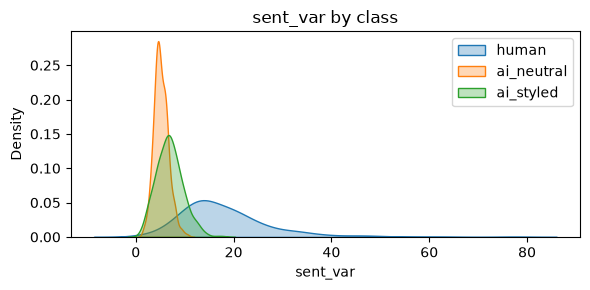

C:\Users\Richa\AppData\Local\Temp\ipykernel_27892\1272597498.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(feats[feats.label == lab][col].dropna(), label=lab, fill=True, alpha=0.3)


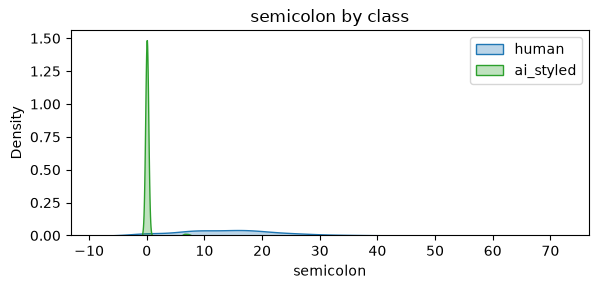

In [ ]:
import seaborn as sns
for col in ["hapax", "sent_var", "semicolon"]:
    plt.figure(figsize=(6, 3))
    for lab in ["human", "ai_neutral", "ai_styled"]:
        sns.kdeplot(feats[feats.label == lab][col].dropna(), label=lab, fill=True, alpha=0.3)
    plt.title(f"{col} by class"); plt.legend(); plt.tight_layout()
    plt.savefig(f"output/task-1/results_task1_{col}_kde.png", dpi=120); plt.show()

## 5. The synthesis visual — PCA projection
If the three classes separate in 2-D *before any ML*, we've proven distinctness.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

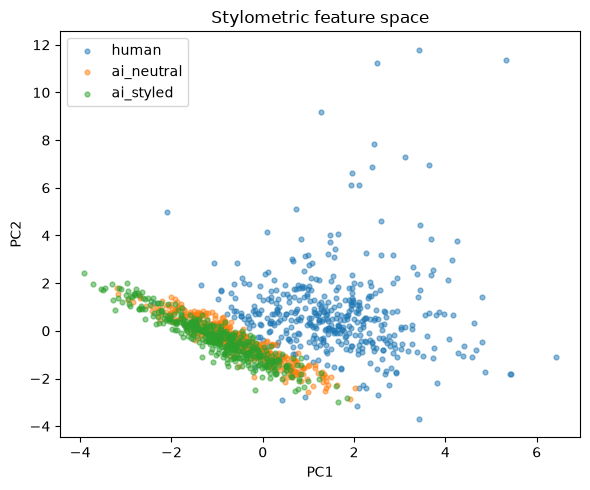

In [17]:
num = feats.drop(columns=["label"]).fillna(feats.mean(numeric_only=True))
X = StandardScaler().fit_transform(num)
pcs = PCA(n_components=2, random_state=42).fit_transform(X)
plt.figure(figsize=(6, 5))
for lab, c in zip(["human", "ai_neutral", "ai_styled"], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    m = feats.label.values == lab
    plt.scatter(pcs[m, 0], pcs[m, 1], s=12, alpha=0.5, label=lab, color=c)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.title("Stylometric feature space")
plt.tight_layout(); plt.savefig("output/task-1/results_task1_pca.png", dpi=120); plt.show()

In [ ]:
feats.to_csv("output/task-1/task1_features.csv", index=False)
print("Saved task1_features.csv — reused as Tier A inputs in Task 2.")

Saved task1_features.csv — reused as Tier A inputs in Task 2.
